# Notebook to explore the Gene Expression data extracted from archs4 H5 file

ref [NIH](https://bioinformatics.ccr.cancer.gov/docs/b4b/RNASeq_Overview/01.Overview/)

Contains documentation for remapping and 
_____

Outputs file path: `/data/FinalExpression/{disease}/expressions(cleaned)/{GSEID}.tsv`

In [1]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import archs4py as a4
import plotly.graph_objects as go
import colorsys
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from typing import Dict, Optional, List

os.getcwd()

'/Users/lingthang/JRaviLab/XLungDisease/Notebooks'

## Initialize Variables

In [ ]:
# General Paths 
TB_expression_path = '../data/FinalExpression/TB'
TB_metadata_path = '../data/metadata/TB'
TB_list = pd.read_csv("../data/CurratedList/TB.tsv", sep = "\t")
TBlabels =	pd.read_csv("../labeling/TB/TB_manCleaned.tsv", sep = "\t")

In [ ]:
# Define the paths
TB_output_path = "../data/expression/cleaned/TB"

# Create directories, creating intermediate ones as necessary.
# exist_ok=True prevents errors if the directory already exists.
os.makedirs(TB_output_path, exist_ok=True)

#### Do all studies have metadata and expression data?

In [5]:
def metadata_expr_match(metadata_dir, expression_dir):
    """
    Returns True if every GSE in metadata_dir (as metadata_GSE########.tsv)
    matches every GSE in expression_dir (as GSE########.tsv),
    and there are no extra GSEs in either directory.
    """
    meta_ids = {
        f[len("metadata_"):-4]
        for f in os.listdir(metadata_dir)
        if f.startswith("metadata_GSE") and f.endswith(".tsv")
    }
    expr_ids = {
        f[:-4]
        for f in os.listdir(expression_dir)
        if f.startswith("GSE") and f.endswith(".tsv")
    }

    # Conditions:
    # 1. All IDs present in both
    # 2. No extras in either dir
    meta_missing = expr_ids - meta_ids
    expr_missing = meta_ids - expr_ids

    match = meta_ids == expr_ids

    if not match:
        print("Mismatch detected:")
        if meta_missing:
            print(f"Missing in metadata: {sorted(meta_missing)}")
        if expr_missing:
            print(f"Missing in expression: {sorted(expr_missing)}")
    return match

# Usage examples:
print("CF:", metadata_expr_match(CF_metadata_path, CF_expression_path))
print("TB:", metadata_expr_match(TB_metadata_path, TB_expression_path))
print("IPF:", metadata_expr_match(IPF_metadata_path, IPF_expression_path))
print("AST:", metadata_expr_match(AST_metadata_path, AST_expression_path))
print("COPD:", metadata_expr_match(COPD_metadata_path, COPD_expression_path))


CF: True
TB: True
IPF: True
AST: True
COPD: True


## Expression Data EDA

In [6]:
def get_expression_shape(path : str, shape : str = None):
    """
    returns the shape of the each file in the directory
    """
    last_dir = os.path.basename(os.path.normpath(path))
    print(f"Number of studies in {last_dir}: {len(os.listdir(path))}")
    
    files = os.listdir(path)
    for file in files:
        if file.endswith('.tsv'):
            df = pd.read_csv(os.path.join(path, file), sep='\t')
            if shape is None:
                print(f"{file}: {df.shape}")
            elif shape == 'rows':
                print(f"{file}: {df.shape[0]} rows")
            elif shape == 'columns':
                print(f"{file}: {df.shape[1]} columns")
            else:
                raise ValueError("Invalid shape argument. Use 'both', 'rows', or 'columns'.")

#### Get Expression File shape

In [7]:
get_expression_shape(TB_expression_path)

Number of studies in TB: 22
GSE236156.tsv: (67186, 36)
GSE164287.tsv: (67186, 9)
GSE148731.tsv: (67186, 25)
GSE183912.tsv: (67186, 9)
GSE211974.tsv: (67186, 7)
GSE132283.tsv: (67186, 13)
GSE165708.tsv: (67186, 33)
GSE143731.tsv: (67186, 9)
GSE174566.tsv: (67186, 37)
GSE256184.tsv: (67186, 17)
GSE141656.tsv: (67186, 7)
GSE223863.tsv: (67186, 29)
GSE193777.tsv: (67186, 47)
GSE148171.tsv: (67186, 10)
GSE64179.tsv: (67186, 13)
GSE198557.tsv: (67186, 13)
GSE143627.tsv: (67186, 7)
GSE112483.tsv: (67186, 84)
GSE121049.tsv: (67186, 7)
GSE84076.tsv: (67186, 11)
GSE64182.tsv: (67186, 7)
GSE112482.tsv: (67186, 88)


#### Get list of relevant samples

In [12]:
# read
Relevant_AST = pd.read_csv("../data/CurratedList/AST.tsv", sep = '\t')
Relevant_CF = pd.read_csv("../data/CurratedList/CF.tsv", sep = '\t')
Relevant_TB = pd.read_csv("../data/CurratedList/TB.tsv", sep = '\t')
Relevant_IPF = pd.read_csv("../data/CurratedList/IPF.tsv", sep = '\t')
Relevant_COPD = pd.read_csv("../data/CurratedList/COPD.tsv", sep = '\t')

Relevant_AST_samples = set(Relevant_AST["GSM_ID"].unique())
Relevant_CF_samples = set(Relevant_CF["GSM_ID"].unique())
Relevant_TB_samples = set(Relevant_TB["GSM_ID"].unique())
Relevant_IPF_samples = set(Relevant_IPF["GSM_ID"].unique())
Relevant_COPD_samples = set(Relevant_COPD["GSM_ID"].unique())

print("Number of relevant samples: ")
print("AST:", len(Relevant_AST_samples))
print("CF:", len(Relevant_CF_samples))
print("TB:", len(Relevant_TB_samples))
print("IPF:", len(Relevant_IPF_samples))
print("COPD:", len(Relevant_COPD_samples))

# Number of relevant samples: 
# AST: 2777
# CF: 107
# TB: 526
# IPF: 517
# COPD: 1006

Number of relevant samples: 
AST: 2777
CF: 107
TB: 520
IPF: 517
COPD: 1006


## Gene Mapping Dictionary Set Up
<a id="GeneMapping"></a>

In [13]:
homo_gene = pd.read_csv("../data/Homo_sapiens.gene_info2025.csv") # 2025
list(homo_gene.columns)

def extract_ensembl_id(dbxref):
    """
    Extracts the Ensembl ENSG ID from a dbXrefs string.
    Returns the ENSG ID if found, else returns None.
    """
    if pd.isna(dbxref):
        return None
    match = re.search(r'Ensembl:(ENSG[0-9]+)', str(dbxref))
    if match:
        return match.group(1)
    return None

# Apply to DataFrame column
homo_gene['Ensembl_ID'] = homo_gene['dbXrefs'].apply(extract_ensembl_id)

# Build symbol+alias to Ensembl ID mapping
symbol_to_ensg = {}
for _, row in homo_gene.iterrows():
    ensg = row['Ensembl_ID']
    if pd.notna(ensg):
        # Add main symbol
        symbol_to_ensg[row['Symbol']] = ensg
        # Add aliases from Synonyms column (pipe or comma separated)
        if pd.notna(row['Synonyms']):
            for alias in str(row['Synonyms']).replace('|', ',').split(','):
                alias = alias.strip()
                if alias and alias != row['Symbol']:
                    symbol_to_ensg[alias] = ensg

print(f"Total unique symbol to Ensembl ID keys: {len(symbol_to_ensg)}")

symbol_alias = {}

# Build a symbol to alias mapping
for _, row in homo_gene.iterrows():
    symbol = row['Symbol']
    if pd.notna(symbol):
        symbol_alias[symbol] = symbol
        if pd.notna(row['Synonyms']):
            for alias in str(row['Synonyms']).replace('|', ',').split(','):
                alias = alias.strip()
                if alias and alias != symbol:
                    symbol_alias[alias] = symbol

print(f"Total unique symbol to alias keys: {len(symbol_alias)}")


gene_to_type = {}

for _, row in homo_gene.iterrows():
    gene_type = row['type_of_gene']
    ensg = row['Ensembl_ID']
    symbol = row['Symbol']

    # Add ENSG ID
    if pd.notna(ensg):
        gene_to_type[ensg] = gene_type

    # Add main symbol
    if pd.notna(symbol):
        gene_to_type[symbol] = gene_type

    # Add aliases (same type as main symbol)
    if pd.notna(row['Synonyms']):
        for alias in str(row['Synonyms']).replace('|', ',').split(','):
            alias = alias.strip()
            if alias and alias != symbol:
                gene_to_type[alias] = gene_type

print(f"Total unique gene to type keys: {len(gene_to_type):,}")

Total unique symbol to Ensembl ID keys: 101068
Total unique symbol to alias keys: 261712
Total unique gene to type keys: 299,831


In [14]:
homo_gene["type_of_gene"].isnull().sum()

0

In [15]:
list(symbol_alias.items())[:10]

[('A1BG', 'A1BG'),
 ('A1B', 'SNTB1'),
 ('ABG', 'A1BG'),
 ('GAB', 'A1BG'),
 ('HYST2477', 'A1BG'),
 ('A2M', 'IGHA2'),
 ('A2MD', 'A2M'),
 ('CPAMD5', 'A2M'),
 ('FWP007', 'A2M'),
 ('S863-7', 'A2M')]

In [16]:
list(symbol_to_ensg.items())[:10]

[('A1BG', 'ENSG00000121410'),
 ('A1B', 'ENSG00000172164'),
 ('ABG', 'ENSG00000121410'),
 ('GAB', 'ENSG00000121410'),
 ('HYST2477', 'ENSG00000121410'),
 ('A2M', 'ENSG00000211890'),
 ('A2MD', 'ENSG00000175899'),
 ('CPAMD5', 'ENSG00000175899'),
 ('FWP007', 'ENSG00000175899'),
 ('S863-7', 'ENSG00000175899')]

In [17]:
list(gene_to_type.items())[:10]

[('ENSG00000121410', 'protein-coding'),
 ('A1BG', 'protein-coding'),
 ('A1B', 'protein-coding'),
 ('ABG', 'protein-coding'),
 ('GAB', 'protein-coding'),
 ('HYST2477', 'protein-coding'),
 ('ENSG00000175899', 'protein-coding'),
 ('A2M', 'other'),
 ('A2MD', 'protein-coding'),
 ('CPAMD5', 'protein-coding')]

In [18]:
# get all the different values in gene_to_type
print(set(gene_to_type.values()))

{'scRNA', 'rRNA', 'protein-coding', 'snoRNA', 'other', 'unknown', 'pseudo', 'ncRNA', 'snRNA', 'biological-region', 'tRNA'}


In [19]:
homo_gene.shape

(193653, 17)

In [20]:
print(homo_gene["type_of_gene"].value_counts())

type_of_gene
biological-region    128261
ncRNA                 22383
protein-coding        20621
pseudo                17494
snoRNA                 1201
unknown                1191
other                   844
rRNA                    785
tRNA                    701
snRNA                   168
scRNA                     4
Name: count, dtype: int64


In [21]:
homo_gene[["Symbol","Ensembl_ID","type_of_gene"]].head()

,Symbol,Ensembl_ID,type_of_gene
0,A1BG,ENSG00000121410,protein-coding
1,A2M,ENSG00000175899,protein-coding
2,NAT1,ENSG00000171428,protein-coding
3,NAT2,ENSG00000156006,protein-coding
4,NATP,None,pseudo


In [22]:
proteincoding_HomoGenes = homo_gene.loc[homo_gene["type_of_gene"] == "protein-coding", ["Symbol", "Ensembl_ID", "type_of_gene"]]
print(proteincoding_HomoGenes.shape)
print(proteincoding_HomoGenes.head())

(20621, 3)
     Symbol       Ensembl_ID    type_of_gene
0      A1BG  ENSG00000121410  protein-coding
1       A2M  ENSG00000175899  protein-coding
2      NAT1  ENSG00000171428  protein-coding
3      NAT2  ENSG00000156006  protein-coding
5  SERPINA3  ENSG00000196136  protein-coding


In [23]:
print(proteincoding_HomoGenes.isnull().sum()) # null values are expected not all genes have Ensembl IDs

Symbol             0
Ensembl_ID      1182
type_of_gene       0
dtype: int64


In [24]:
genetypedf = homo_gene[["Symbol", "Ensembl_ID", "type_of_gene"]]
print(genetypedf.shape)
genetypedf.head()

(193653, 3)


,Symbol,Ensembl_ID,type_of_gene
0,A1BG,ENSG00000121410,protein-coding
1,A2M,ENSG00000175899,protein-coding
2,NAT1,ENSG00000171428,protein-coding
3,NAT2,ENSG00000156006,protein-coding
4,NATP,None,pseudo


In [25]:
print(genetypedf.isnull().sum())

Symbol               0
Ensembl_ID      155257
type_of_gene         0
dtype: int64


In [26]:
print(genetypedf["type_of_gene"].value_counts())

type_of_gene
biological-region    128261
ncRNA                 22383
protein-coding        20621
pseudo                17494
snoRNA                 1201
unknown                1191
other                   844
rRNA                    785
tRNA                    701
snRNA                   168
scRNA                     4
Name: count, dtype: int64


## Subset for relevant samples only

In [27]:
def filter_gsm_columns(path: str, AcceptableGSM: set, outputpath: str = None):
    """
    For each .tsv file in 'path', drops columns (GSMs) not in AcceptableGSM.
    If outputpath is provided, saves filtered DataFrames there.
    Otherwise, returns a dict of filtered DataFrames.
    Never edits files in the given path.
    """
    filtered_dfs = {}
    if outputpath and not os.path.exists(outputpath):
        os.makedirs(outputpath)
    for fname in os.listdir(path):
        if fname.endswith('.tsv'):
            fpath = os.path.join(path, fname)
            df = pd.read_csv(fpath, sep='\t')
            gene_col = df.columns[0]
            gsm_cols = [col for col in df.columns[1:] if col in AcceptableGSM]
            keep_cols = [gene_col] + gsm_cols
            filtered_df = df[keep_cols]
            if outputpath:
                out_fpath = os.path.join(outputpath, fname)
                filtered_df.to_csv(out_fpath, sep='\t', index=False)
            else:
                filtered_dfs[fname] = filtered_df
    if not outputpath:
        return filtered_dfs

In [ ]:
filter_gsm_columns(TB_expression_path, Relevant_TB_samples, TB_output_path)

#### Subest for relevant samples only

In [29]:
get_expression_shape(TB_output_path)

Number of studies in TB: 22
GSE236156.tsv: (67186, 36)
GSE164287.tsv: (67186, 9)
GSE148731.tsv: (67186, 25)
GSE183912.tsv: (67186, 9)
GSE211974.tsv: (67186, 7)
GSE132283.tsv: (67186, 13)
GSE165708.tsv: (67186, 33)
GSE143731.tsv: (67186, 9)
GSE174566.tsv: (67186, 37)
GSE256184.tsv: (67186, 17)
GSE141656.tsv: (67186, 7)
GSE223863.tsv: (67186, 29)
GSE193777.tsv: (67186, 47)
GSE148171.tsv: (67186, 10)
GSE64179.tsv: (67186, 13)
GSE198557.tsv: (67186, 13)
GSE143627.tsv: (67186, 7)
GSE112483.tsv: (67186, 84)
GSE121049.tsv: (67186, 7)
GSE84076.tsv: (67186, 11)
GSE64182.tsv: (67186, 7)
GSE112482.tsv: (67186, 88)


### Histogram of Gene Type Distribution within Series across Diseases

Using existing gene_to_type map with 299831 entries.

Generating Stacked Gene Type Histograms for all diseases...


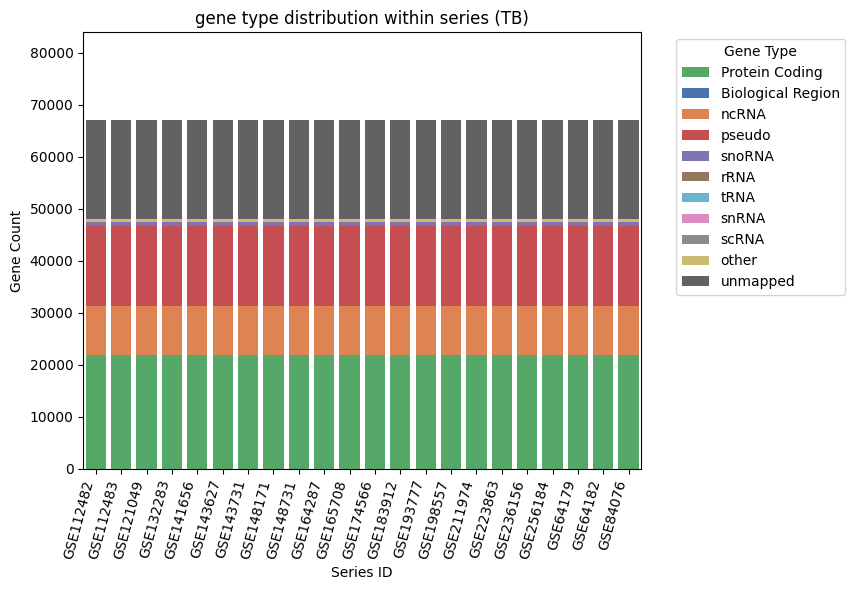

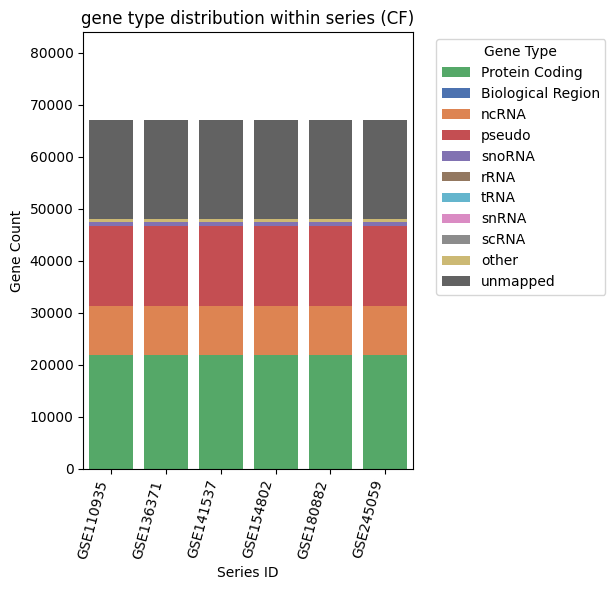

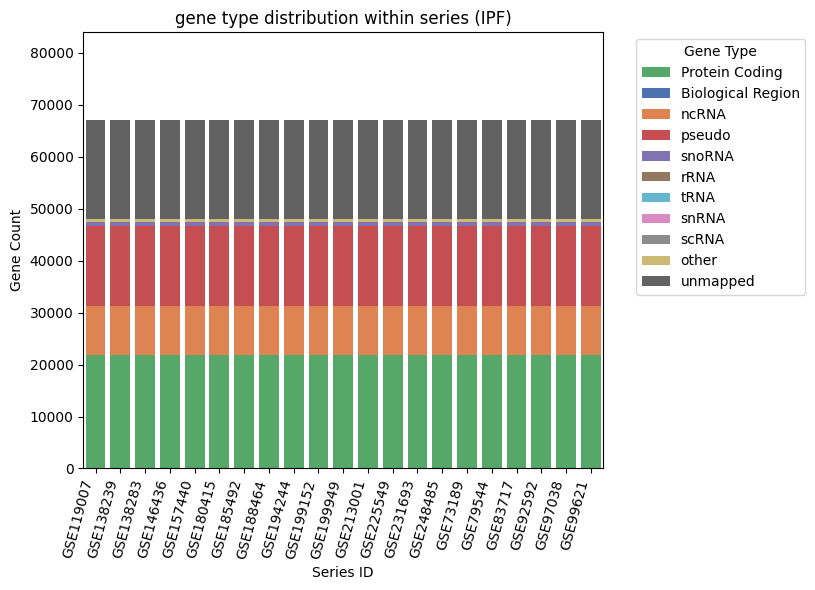

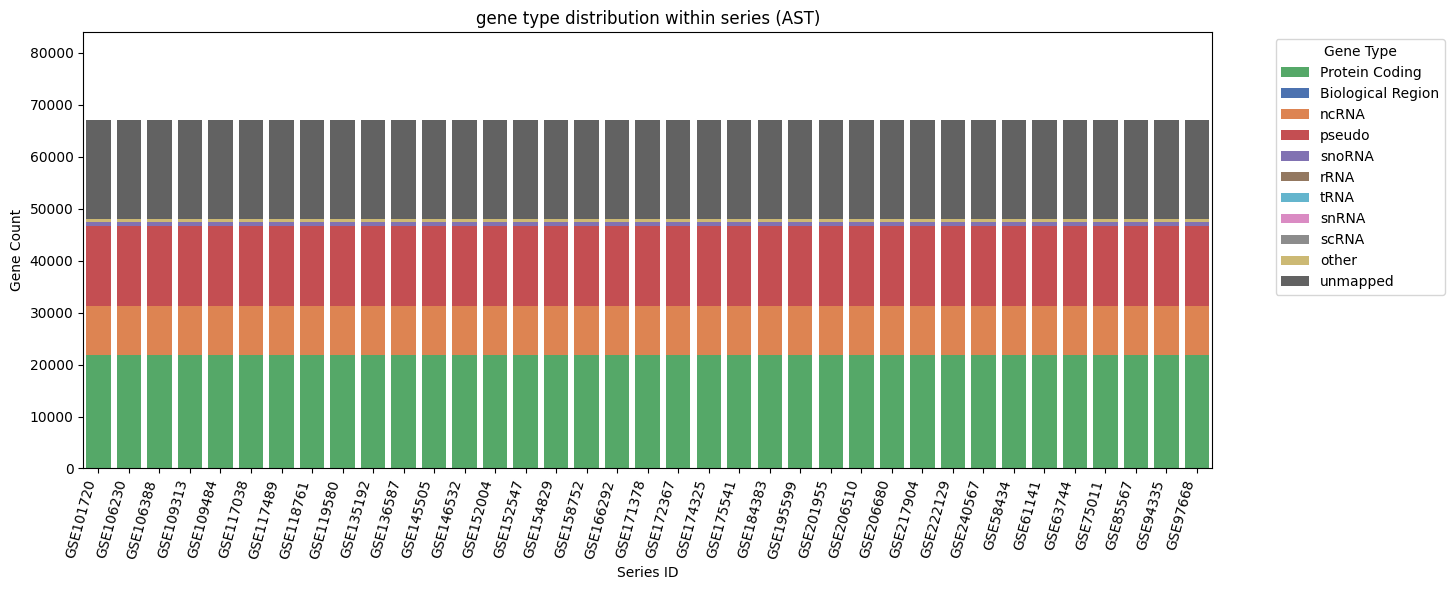

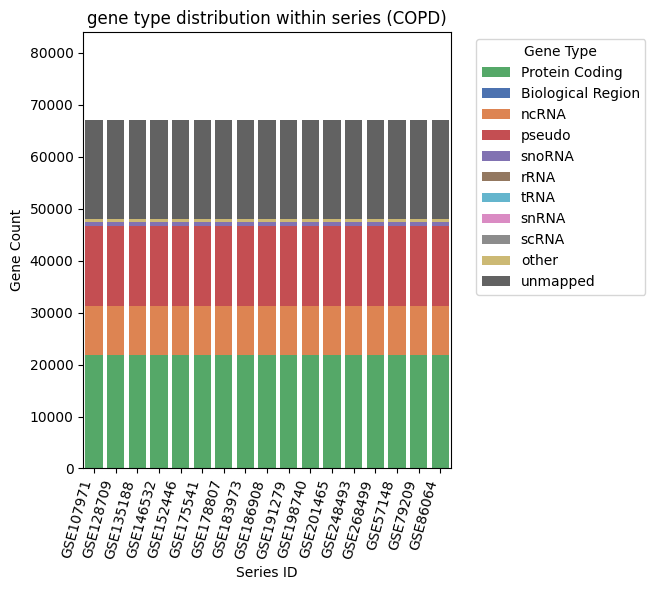

In [66]:
DISEASES = {
    'TB': TB_expression_path,
    'CF': CF_expression_path,
    'IPF': IPF_expression_path,
    'AST': AST_expression_path,
    'COPD': COPD_expression_path
}

# Define a consistent set of colors for the most common gene types observed 
GENE_TYPE_COLORS = {
    'protein-coding': '#55A868',     # balanced green
    'biological-region': '#4C72B0',  # soft blue
    'ncRNA': '#DD8452',              # warm amber
    'pseudo': '#C44E52',             # deep rose
    'snoRNA': '#8172B2',             # muted violet
    'rRNA': '#937860',               # earthy brown
    'tRNA': '#64B5CD',               # teal-blue
    'snRNA': '#DA8BC3',              # light magenta
    'scRNA': '#8C8C8C',              # neutral gray
    'other': '#CCB974',              # olive-gold
    'unmapped': "#626262"            # grey
}
# Define the preferred order for stacking and legend
ORDERED_TYPES = [
'protein-coding', 
'biological-region', 
'ncRNA', 
'pseudo', 
'snoRNA', 
'rRNA', 
'tRNA', 
'snRNA', 
'scRNA',
'other', 
'unmapped', 
]

def plot_gene_type_distribution(path_to_expression: str, disease: str, gene_to_type_map: Dict[str, str], colors: Dict[str, str], ordered_types: List[str]):
    """
    Creates a stacked histogram plot of the specific 'type_of_gene' distribution
    for each study (Series) in a given disease directory, by mapping the gene
    identifiers in the expression files to the provided gene_to_type_map.
    """
    
    if not os.path.exists(path_to_expression):
        print(f"Error: Directory not found for {disease}: {path_to_expression}")
        return

    files = [f for f in os.listdir(path_to_expression) if f.endswith('.tsv')]
    
    if not files:
        print(f"No TSV files found in {path_to_expression}. Skipping {disease}.")
        return

    all_gene_type_counts: Dict[str, Dict[str, int]] = {}
    study_names = []

    for file in files:
        file_path = os.path.join(path_to_expression, file)
        try:
            # gene name in col 1 
            df = pd.read_csv(file_path, sep='\t')
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue
        
        gene_col = df.columns[0]
        
        # Map the gene identifiers to their type, 'unmapped' if gene does not exist in the dict
        df['type_of_gene'] = df[gene_col].astype(str).map(lambda x: gene_to_type_map.get(x, 'unmapped'))
        
        # get count 
        counts = df.loc[df[gene_col].notna(), 'type_of_gene'].value_counts().to_dict()
        
        study_name = file.replace('.tsv', '')
        all_gene_type_counts[study_name] = counts
        study_names.append(study_name)

    # prep data for plotting
    if not all_gene_type_counts:
        print(f"No gene type data to plot for {disease}.")
        return

    # Create a consolidated DataFrame from the counts dictionary
    plot_df = pd.DataFrame.from_dict(all_gene_type_counts, orient='index').fillna(0)
    plot_df.index.name = 'study_name'
    plot_df = plot_df.sort_index()

    # Determine the actual types found, and reindex for consistent ordering
    # Ensure 'unmapped' is at the end if present
    actual_types = [t for t in ordered_types if t in plot_df.columns]
    if 'unmapped' in plot_df.columns and 'unmapped' not in actual_types:
        actual_types.append('unmapped')
    plot_df = plot_df.reindex(columns=actual_types, fill_value=0)

    # Plotting 
    study_names = plot_df.index.tolist()
    total_heights = plot_df.sum(axis=1).values
    max_height = total_heights.max() if len(total_heights) > 0 else 1

    plt.figure(figsize=(max(8, len(study_names)*0.5), 6))
    
    bottom_array = np.zeros(len(study_names))

    # Iterate through gene types in the ordered list to create the stacked bars
    for gene_type in actual_types:
        counts = plot_df[gene_type].values
        color = colors.get(gene_type, colors['other'])
        
        # Replace hyphens and capitalize for a clean legend label
        if '-' in gene_type:
            # For types like 'protein-coding'
            label = gene_type.replace('-', ' ').title()
        else:
            # For types like 'ncRNA', 'rRNA', 'pseudo'
            label = gene_type

        plt.bar(study_names, counts, bottom=bottom_array, 
                label=label, color=color)
        
        # Update the bottom for the next type
        bottom_array += counts

    # Finalize plot limits and labels
    plt.ylim(top=max_height * 1.25)
    plt.xlim([-0.5, len(study_names) - 0.5])
    
    plt.xticks(rotation=75, ha='right')
    plt.ylabel('Gene Count')
    plt.xlabel('Series ID')
    plt.title(f'gene type distribution within series ({disease})')
    
    # Place legend outside the plot area
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0), title="Gene Type")
    
    plt.tight_layout(rect=[0, 0, 0.8, 1]) 

    # Save the figure
    save_dir = 'images/GeneTypeDistribution'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}/{disease}_GeneTypeDistribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# Use gene_to_type dict defined earlier
if 'gene_to_type' in globals() and isinstance(gene_to_type, dict) and gene_to_type:
    gene_map = gene_to_type
    print(f"Using existing gene_to_type map with {len(gene_map)} entries.")
    
    print("\nGenerating Stacked Gene Type Histograms for all diseases...")
    for disease, path in DISEASES.items():
        plot_gene_type_distribution(path, disease, gene_map, GENE_TYPE_COLORS, ORDERED_TYPES)
else:
    print("gene_to_type not found or empty. Cannot proceed with plotting.")

## Subset for protein coding genes only

In [37]:
# protein coding gene only
def filter_protein_coding_genes(expressionpath : str, gene_to_type: Dict[str, str], save : bool = False) -> pd.DataFrame:
	"""
	Given a path to an folder containing expression .tsv files, where dims are gene x samples,
	perform filtering to keep only protein coding genes based on gene_to_type mapping.

	if save is True, saves each DataFrames back to the same files, else returns a dictionary of filtered DataFrames.
	
	"""
	files = os.listdir(expressionpath)
	filtered_dfs = {}
	for file in files:
		if file.endswith('.tsv'):
			fpath = os.path.join(expressionpath, file)
			df = pd.read_csv(fpath, sep = '\t')
			gene_col = df.columns[0]
			# Identify protein-coding genes
			protein_coding_genes = [
				gene for gene in df[gene_col]
				if gene in gene_to_type and gene_to_type[gene] == 'protein-coding'
			]
			# Filter DataFrame
			filtered_df = df[df[gene_col].isin(protein_coding_genes)]
			if save:
				filtered_df.to_csv(fpath, sep = '\t', index = False)
			else:
				filtered_dfs[file] = filtered_df
	if not save:
		return filtered_dfs

#### Filter and save protein coding genes only

In [63]:
TB_filteredpc = filter_protein_coding_genes(TB_output_path, gene_to_type, save = True)

Using existing gene_to_type map with 299831 entries.

Generating Stacked Gene Type Histograms for all diseases...


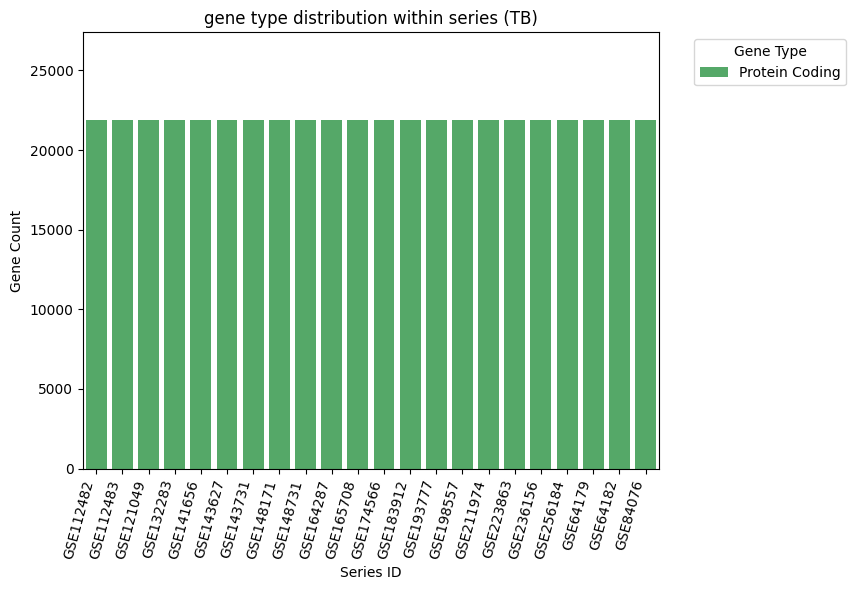

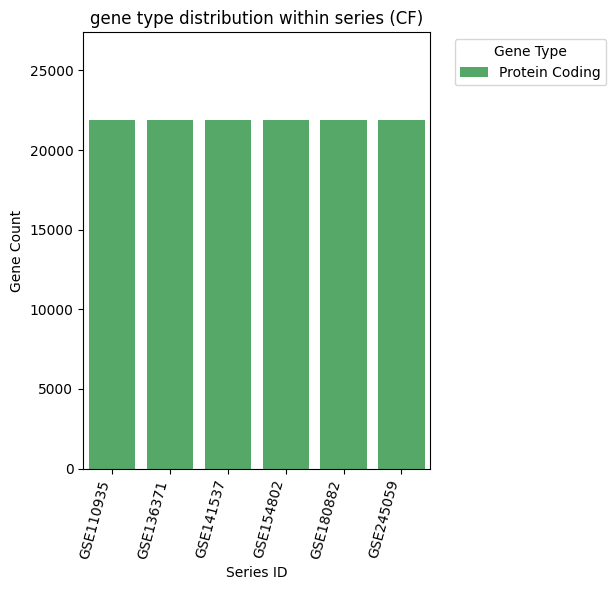

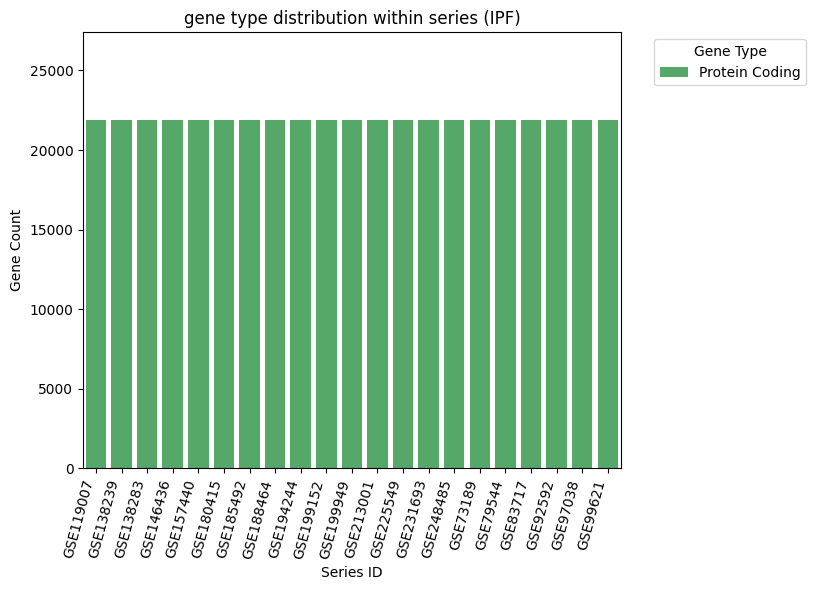

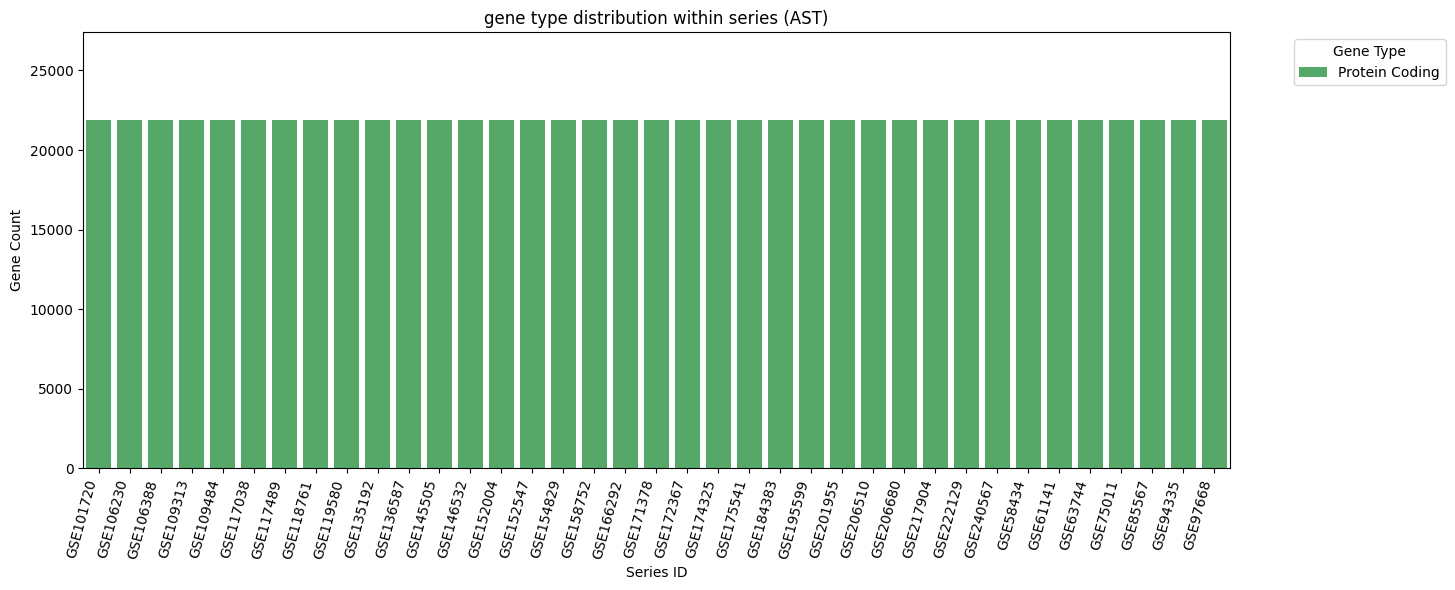

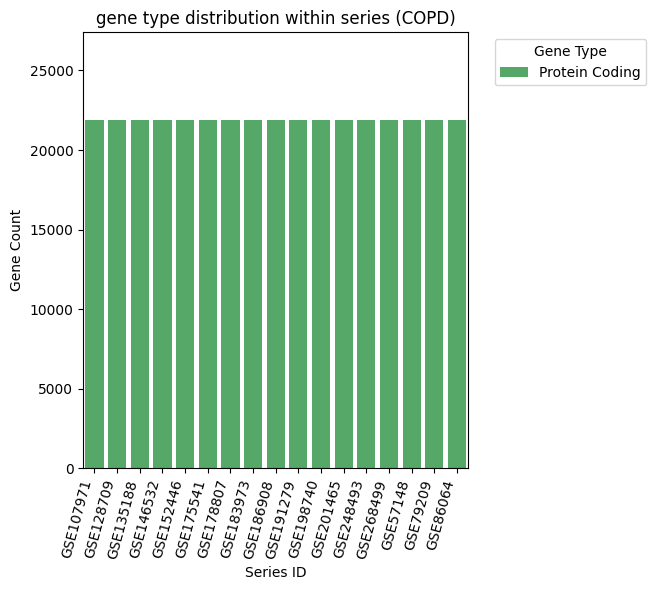

In [43]:
DISEASES = {
    'TB': TB_output_path,
    'CF': CF_output_path,
    'IPF': IPF_output_path,
    'AST': AST_output_path,
    'COPD': COPD_output_path
}

if 'gene_to_type' in globals() and isinstance(gene_to_type, dict) and gene_to_type:
    gene_map = gene_to_type
    print(f"Using existing gene_to_type map with {len(gene_map)} entries.")
    
    print("\nGenerating Stacked Gene Type Histograms for all diseases...")
    for disease, path in DISEASES.items():
        plot_gene_type_distribution(path, disease, gene_map, GENE_TYPE_COLORS, ORDERED_TYPES)
else:
    print("gene_to_type not found or empty. Cannot proceed with plotting.")

# Function to remove low quality reads

## Remove low quality reads

- Rows where 50% or more of the columns is 0
- Rows where 90% or more of the row are 0
- Remove Rows where the gene name is missing or NaN

In [44]:
def remove_low_quality_reads(path, print_shape=False):
    """
    Cleans gene expression files by removing:
    - Columns where 50% or more of the columns is 0
    - Rows where 90% or more of the row are 0
    - Remove Rows where the gene name is missing or NaN
    Args:
        path (str): directory containing .tsv files
        print_shape (bool): if True, prints the shape of each cleaned DataFrame

    Returns:
        dict: cleaned DataFrames keyed by filename
    """
    cleaned_dfs = {}
    if not os.path.exists(path):
        print(f"Error: Path not found: {path}")
        return cleaned_dfs
        
    for file in os.listdir(path):
        if file.endswith('.tsv'):
            file_path = os.path.join(path, file)
            df = pd.read_csv(file_path, sep='\t')
            
            # remove rows where the gene name is na
            initial_row_count = df.shape[0]
            df = df[df.iloc[:, 0].notna()].copy()
            
            # Remove columns where 50% or more values are 0
            # Use all columns except the first for numeric operations
            numeric_cols_df = df.iloc[:, 1:] 
            
            # Identify columns to KEEP: where the number of zeros is LESS than 50% of the rows
            col_threshold = 0.5 * numeric_cols_df.shape[0] 
            # Filter keeps columns where zero count < threshold, which is correct
            cols_to_keep_mask = (numeric_cols_df == 0).sum(axis=0) < col_threshold 
            
            # Apply the filter to numeric columns and then concatenate with the first column
            numeric_cols_cleaned = numeric_cols_df.loc[:, cols_to_keep_mask]
            df_col_cleaned = pd.concat([df.iloc[:, [0]], numeric_cols_cleaned], axis=1)

            # remove rows where 90% or more values are 0 
            numeric_cols_df = df_col_cleaned.iloc[:, 1:]
            
            # Identify rows to KEEP: where the number of NON-ZEROS is GREATER than 10% of the columns
            # This is equivalent to removing rows where number of ZEROS is >= 90% of the columns.
            row_non_zero_threshold = 0.1 * numeric_cols_df.shape[1] 
            
            # mask counts non-zeros and checks if the count is > the 10% threshold (meaning < 90% zeros)
            mask = (numeric_cols_df != 0).sum(axis=1) > row_non_zero_threshold 
            
            df_cleaned = df_col_cleaned.loc[mask].copy()
            
            if print_shape:
                print(f"{file}: Original Shape ({initial_row_count}, {df.shape[1]}). Cleaned Shape {df_cleaned.shape}")
                
            cleaned_dfs[file] = df_cleaned
            
    return cleaned_dfs

# Function to remap the gene symbols to Ensembl IDs

**to be chained with remove_low_count_reads()**

```python
remapping(remove_low_count_reads())
```

In [45]:
def remapping(cleaned_dfs, output_path=None):
    """
    - Drops "linc" genes
    - Remaps gene using `symbol_to_ensg`
    - Keeps symbol for unmapped genes (no ENSG)
    - Drops duplicates after remapping
    - Optionally saves output
    - Prints a summary for each file

    Returns:
        dict: remapped and cleaned DataFrames
    """
    remapped_dfs = {}

    print(f"\n{'File':<20}{'Post-Filter':>12}{'LINC Dropped':>14}"
          f"{'Unmapped':>10}{'Post-Remap':>12}{'Duplicates':>12}"
          f"{'Final Rows':>12}")
    
    for filename, df in cleaned_dfs.items():
        df = df.copy()
        first_col = df.columns[0]
        pre_remap_rows = df.shape[0]

        # Drop 'linc' genes
        linc_mask = df[first_col].str.lower().str.startswith('linc')
        linc_count = linc_mask.sum()
        df = df.loc[~linc_mask].copy()

        # Remap: keep value if not in dict
        mapped = df[first_col].map(lambda x: symbol_to_ensg.get(x, x))
        unmapped_count = (~df[first_col].isin(symbol_to_ensg.keys())).sum()
        df.loc[:, first_col] = mapped

        # Count duplicates
        duplicate_count = df[first_col].duplicated().sum()
        post_remap_rows = df.shape[0]

        # Drop duplicates
        df = df.drop_duplicates(subset=[first_col])
        final_rows = df.shape[0]

        # Print report line
        print(f"{filename:<20}{pre_remap_rows:>12}{linc_count:>14}"
              f"{unmapped_count:>10}{post_remap_rows:>12}"
              f"{duplicate_count:>12}{final_rows:>12}")

        # Save if path is given
        if output_path:
            output_file = os.path.join(output_path, filename)
            df.to_csv(output_file, sep='\t', index=False)

        remapped_dfs[filename] = df

    return remapped_dfs

# Process all the expression data files

In [47]:
TBcleaned = remapping(remove_low_quality_reads(TB_output_path), TB_output_path)


File                 Post-Filter  LINC Dropped  Unmapped  Post-Remap  Duplicates  Final Rows
GSE236156.tsv              16883             0     16883       16883           0       16883
GSE164287.tsv              16764             0     16764       16764           0       16764
GSE148731.tsv              16019             0     16019       16019           0       16019
GSE183912.tsv              15715             0     15715       15715           0       15715
GSE211974.tsv              16906             0     16906       16906           0       16906
GSE132283.tsv              18292             0     18292       18292           0       18292
GSE165708.tsv              16623             0     16623       16623           0       16623
GSE143731.tsv              16592             0     16592       16592           0       16592
GSE174566.tsv              17406             0     17406       17406           0       17406
GSE256184.tsv              17525             0     17525       17525 

## Verify Integrity

* get a count of genes vs Ensemble IDs
* make sure there are no duplicate Ensemble IDs

In [52]:
def verify_process(path: str):
    """
    For each .tsv file in the given path:
    - Prints the total number of genes (rows)
    - Prints the number of Ensembl IDs (rows where first col starts with 'ENSG')
    - Prints the number of gene symbols (rows where first col does NOT start with 'ENSG')
    - Checks for duplicate Ensembl IDs
    - Checks for duplicate gene names (using symbol_alias mapping)
    - Prints if any file has duplicates before printing details
    """
    files = [f for f in os.listdir(path) if f.endswith('.tsv')]
    has_ensg_duplicates = False
    has_symbol_duplicates = False
    for file in files:
        df = pd.read_csv(os.path.join(path, file), sep='\t')
        gene_col = df.columns[0]
        ensg_mask = df[gene_col].astype(str).str.startswith('ENSG')
        # Check for duplicate Ensembl IDs
        if df.loc[ensg_mask, gene_col].duplicated().any():
            has_ensg_duplicates = True
        # Check for duplicate gene names (map all to canonical symbol, then check dups)
        mapped_symbols = df.loc[~ensg_mask, gene_col].map(lambda x: symbol_alias.get(x, x))
        if mapped_symbols.duplicated().any():
            has_symbol_duplicates = True
    
    print("Duplicates present in any file:" if has_ensg_duplicates or has_symbol_duplicates else "No duplicates found in any file.")
    if has_ensg_duplicates:
        print("- Duplicate Ensembl IDs found.")
    if has_symbol_duplicates:
        print("- Duplicate gene names (canonical symbol) found.")
    
    print(f"{'File':<20}{'Total Genes':>12}{'Ensembl IDs':>14}{'Gene Symbols':>14}{'ENSG Duplicates':>16}{'Symbol Duplicates':>18}")
    for file in files:
        df = pd.read_csv(os.path.join(path, file), sep='\t')
        gene_col = df.columns[0]
        total_genes = df.shape[0]
        ensg_mask = df[gene_col].astype(str).str.startswith('ENSG')
        ensg_count = ensg_mask.sum()
        symbol_count = total_genes - ensg_count
        ensg_duplicates = df.loc[ensg_mask, gene_col].duplicated().sum()
        mapped_symbols = df.loc[~ensg_mask, gene_col].map(lambda x: symbol_alias.get(x, x))
        symbol_duplicates = mapped_symbols.duplicated().sum()
        print(f"{file:<20}{total_genes:>12}{ensg_count:>14}{symbol_count:>14}{ensg_duplicates:>16}{symbol_duplicates:>18}")

In [53]:
verify_process(TB_output_path)

No duplicates found in any file.
File                 Total Genes   Ensembl IDs  Gene Symbols ENSG Duplicates Symbol Duplicates
GSE236156.tsv              16883         16858            25               0                 0
GSE164287.tsv              16764         16736            28               0                 0
GSE148731.tsv              16019         15997            22               0                 0
GSE183912.tsv              15715         15694            21               0                 0
GSE211974.tsv              16906         16882            24               0                 0
GSE132283.tsv              18292         18257            35               0                 0
GSE165708.tsv              16623         16599            24               0                 0
GSE143731.tsv              16592         16570            22               0                 0
GSE174566.tsv              17406         17376            30               0                 0
GSE256184.tsv    

#### Filter and save protein coding genes only

Using existing gene_to_type map with 299831 entries.

Generating Stacked Gene Type Histograms for all diseases...


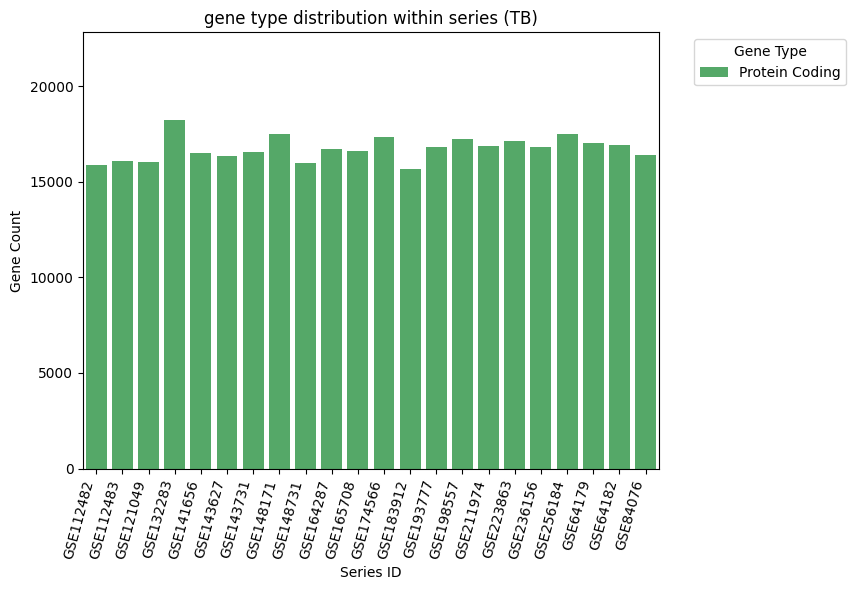

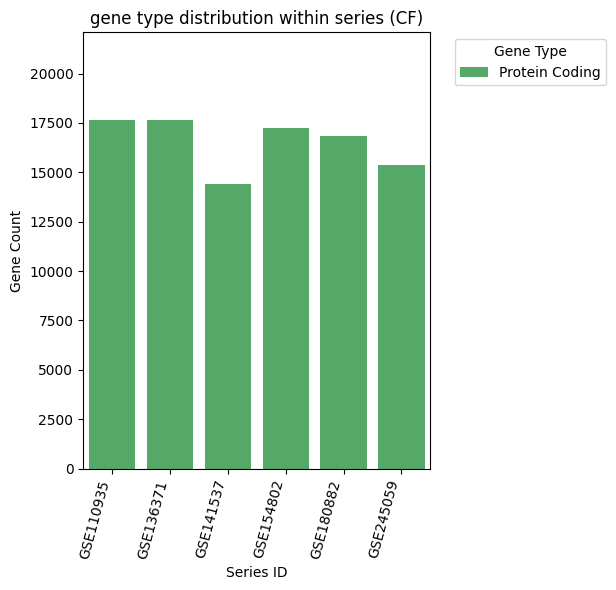

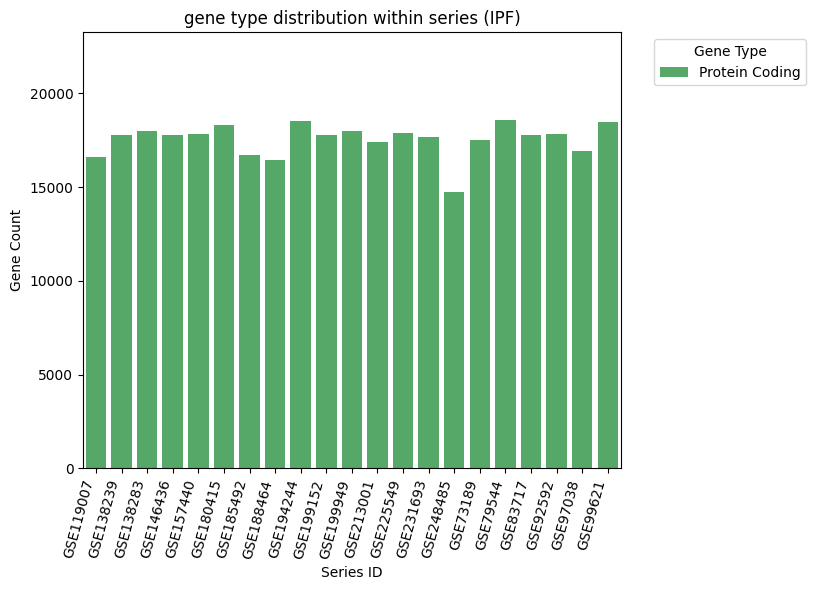

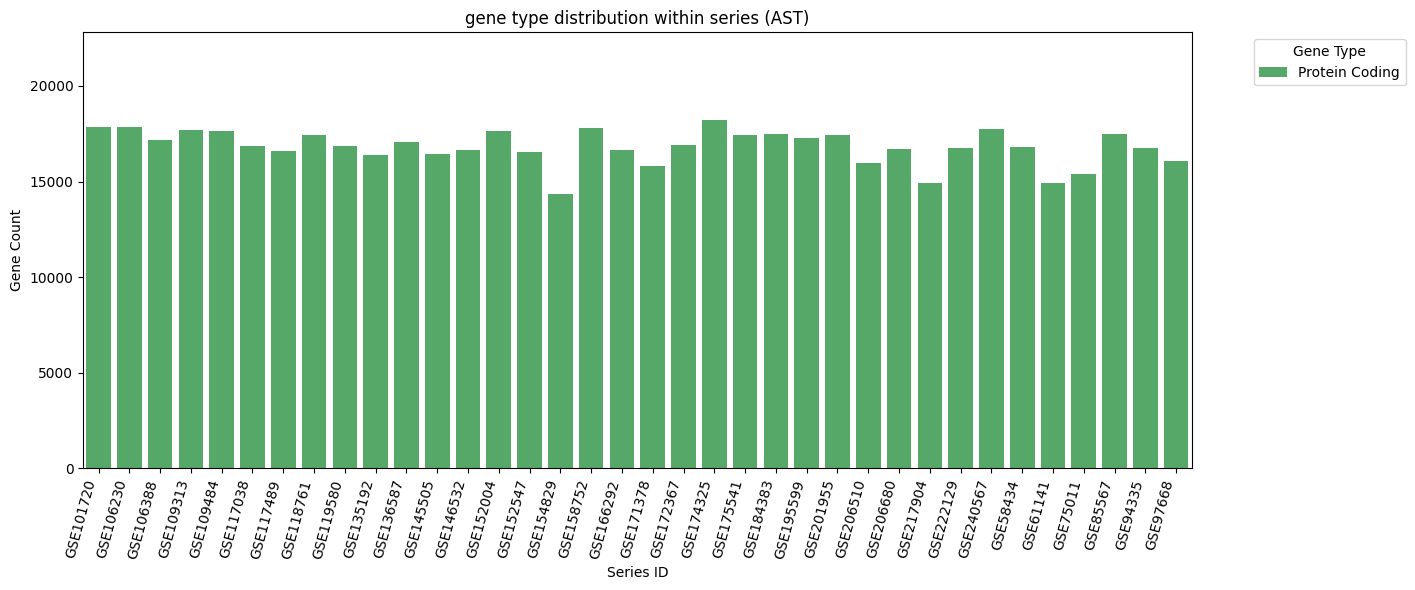

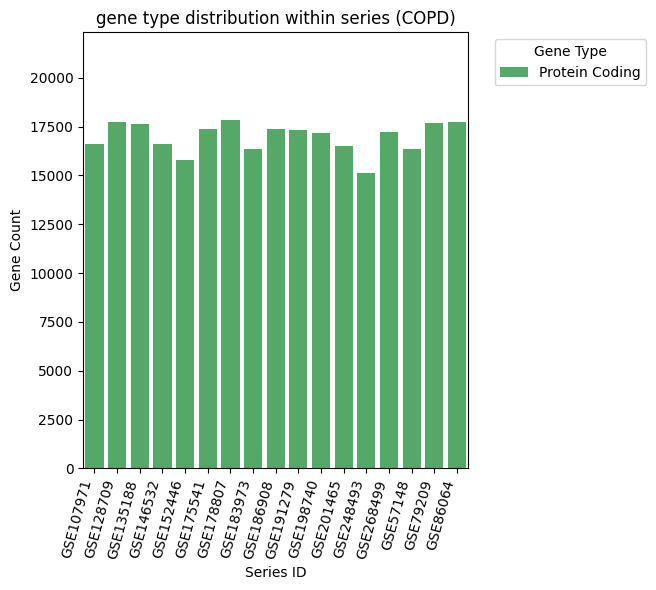

In [64]:
if 'gene_to_type' in globals() and isinstance(gene_to_type, dict) and gene_to_type:
    gene_map = gene_to_type
    print(f"Using existing gene_to_type map with {len(gene_map)} entries.")
    
    print("\nGenerating Stacked Gene Type Histograms for all diseases...")
    for disease, path in DISEASES.items():
        plot_gene_type_distribution(path, disease, gene_map, GENE_TYPE_COLORS, ORDERED_TYPES)
else:
    print("gene_to_type not found or empty. Cannot proceed with plotting.")

# Data Visualization

* visualize distribution of expression values across samples
* visualize the single cell probability of each series

### Get single cell probability for each series

In [ ]:
# extract the gse_ids
TB_gse_ids = TB_list['GSE_ID'].unique().tolist()

# Extract the list of GSM IDs for each disease
tb_gsm_ids = TB_list['GSM_ID'].tolist()

file = "../data/human_gene_v2.5.h5"
a4.ls(file)

data                      
│ expression            uint32 | (67186, 888821)
meta                      
│ genes                     
│   biotype               str    | (67186,)
│   ensembl_gene          str    | (67186,)
│   symbol                str    | (67186,)
│ info                      
│   author                str    | ()
│   contact               str    | ()
│   creation-date         str    | ()
│   laboratory            str    | ()
│   version               str    | ()
│ samples                   
│   channel_count         str    | (888821,)
│   characteristics_ch1   str    | (888821,)
│   contact_address       str    | (888821,)
│   contact_city          str    | (888821,)
│   contact_country       str    | (888821,)
│   contact_institute     str    | (888821,)
│   contact_name          str    | (888821,)
│   contact_zip           str    | (888821,)
│   data_processing       str    | (888821,)
│   extract_protocol_ch1  str    | (888821,)
│   geo_accession         str    | (88

In [ ]:
print("TB_gse_ids:", len(TB_gse_ids))

TB_gse_ids: 22
AST_gse_ids: 37
CF_gse_ids: 6
IPF_gse_ids: 21
COPD_gse_ids: 17


In [69]:
def series_singlecellprobability(df, disease : None):
	series_probability = df.groupby('series_id')['singlecellprobability'].mean().reset_index()

	print(f"\nAverage single cell probability per series for {disease}:")
	print(series_probability)
	return series_probability

In [73]:
tb_meta = a4.meta.samples(file=file, samples=tb_gsm_ids, meta_fields=fetch_info)
print(tb_meta)

           geo_accession          series_id singlecellprobability
GSM1565955    GSM1565955  GSE64179,GSE64183               0.03184
GSM1565956    GSM1565956  GSE64179,GSE64183              0.020636
GSM1565957    GSM1565957  GSE64179,GSE64183              0.002149
GSM1565958    GSM1565958  GSE64179,GSE64183              0.039045
GSM1565959    GSM1565959  GSE64179,GSE64183                   0.0
...                  ...                ...                   ...
GSM8087252    GSM8087252          GSE256184              0.007814
GSM8087253    GSM8087253          GSE256184              0.011228
GSM8087254    GSM8087254          GSE256184              0.005497
GSM8087255    GSM8087255          GSE256184              0.002195
GSM8087256    GSM8087256          GSE256184              0.011228

[496 rows x 3 columns]


In [74]:
tbscp = series_singlecellprobability(tb_meta, "TB")


Average single cell probability per series for TB:
              series_id singlecellprobability
0             GSE112482              0.314966
1             GSE112483              0.060914
2             GSE121049              0.003865
3             GSE132283              0.003567
4             GSE141656              0.005133
5             GSE143627              0.002882
6             GSE143731              0.004107
7             GSE148171              0.011476
8             GSE148731              0.003604
9             GSE164287              0.004776
10  GSE165708,GSE165709              0.002449
11            GSE174566              0.002259
12            GSE183912              0.002079
13            GSE193777              0.008689
14            GSE198557              0.029175
15  GSE211974,GSE211977              0.006548
16            GSE223863              0.004504
17            GSE236156              0.034067
18            GSE256184              0.017399
19    GSE64179,GSE64183     

### Visualize Sparsity of expression matrix on Raw Gene Counts

In [79]:
def plot_stacked_gene_type_histogram(path, scp=None, disease_name=None):
    """
    Plots a stacked bar chart of gene symbol vs Ensembl ID counts per study.
    If scp is provided, annotates each bar with the single cell probability and
    colors the annotation with a green-to-red gradient based on probability.
    """
    files = [f for f in os.listdir(path) if f.endswith('.tsv')]
    ensg_counts = []
    symbol_counts = []
    study_names = []

    for file in files:
        df = pd.read_csv(os.path.join(path, file), sep='\t')
        gene_col = df.columns[0]
        ensg_mask = df[gene_col].astype(str).str.startswith('ENSG')
        ensg_counts.append(ensg_mask.sum())
        symbol_counts.append((~ensg_mask).sum())
        study_names.append(file.replace('.tsv', ''))
    
    # Calculate total heights and find the index of the tallest bar
    total_heights = np.array(ensg_counts) + np.array(symbol_counts)
    max_height = total_heights.max()
    
    # --- DYNAMIC LEGEND LOGIC ---
    # Find the position of the tallest bar
    tallest_bar_index = np.argmax(total_heights)
    
    # If the tallest bar is in the right half of the plot, place legend on the left.
    if tallest_bar_index > len(study_names) / 2:
        legend_loc = 'upper left'
    else:
        legend_loc = 'upper left' # right but changed for the sake of uniformity

    plt.figure(figsize=(max(8, len(study_names)*0.5), 6))
    plt.bar(study_names, ensg_counts, label='Ensembl IDs', color='#8da0cb')
    plt.bar(study_names, symbol_counts, bottom=ensg_counts, label='Gene Symbols', color='#fc8d62')

    if scp is not None:
        scp = scp.copy()
        scp['singlecellprobability'] = pd.to_numeric(scp['singlecellprobability'], errors='coerce')
        scp_map = {}
        for idx, row in scp.iterrows():
            for sid in str(row['series_id']).split(','):
                scp_map[sid.strip()] = row['singlecellprobability']
        
        cmap = plt.get_cmap('RdYlGn_r')
        norm = mcolors.Normalize(vmin=0, vmax=1)
        annotation_offset = max_height * 0.03

        for i, study in enumerate(study_names):
            prob = None
            for sid in scp_map:
                if study == sid or study in sid or sid in study:
                    prob = scp_map[sid]
                    break
            if prob is not None and not np.isnan(prob):
                color = cmap(norm(prob))
                plt.text(i, ensg_counts[i] + symbol_counts[i] + annotation_offset,
                         f"{prob:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)
            else:
                plt.text(i, ensg_counts[i] + symbol_counts[i] + annotation_offset,
                         "NA", ha='center', va='bottom', fontsize=8, color='gray')

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        ax = plt.gca() 
        cbar = plt.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label('Single Cell Probability', labelpad=15)

    # Consolidated axis limit settings
    plt.ylim(top=max_height * 1.25) # Use a single ylim call for 25% headroom
    plt.xlim([-0.5, len(study_names) - 0.5]) # Remove extra padding on the sides
    
    plt.xticks(rotation=75, ha='right')
    plt.ylabel('Gene Count')
    plt.xlabel('Study')
    plt.title(f'Stacked Gene Type Histogram per Study{f" ({disease_name})" if disease_name else ""}')
    
    # Use the dynamically chosen location for the legend
    plt.legend(loc=legend_loc)
    
    plt.tight_layout(pad=2.0)
    # save 
    
    if scp is not None and disease_name is not None:
        plt.savefig(f'images/GeneExpression/{disease_name}GeneExpression-SCP.png', dpi=300)
    if scp is None and disease_name is not None:
        plt.savefig(f'images/GeneExpression/{disease_name}GeneExpression.png', dpi=300)
    plt.show()

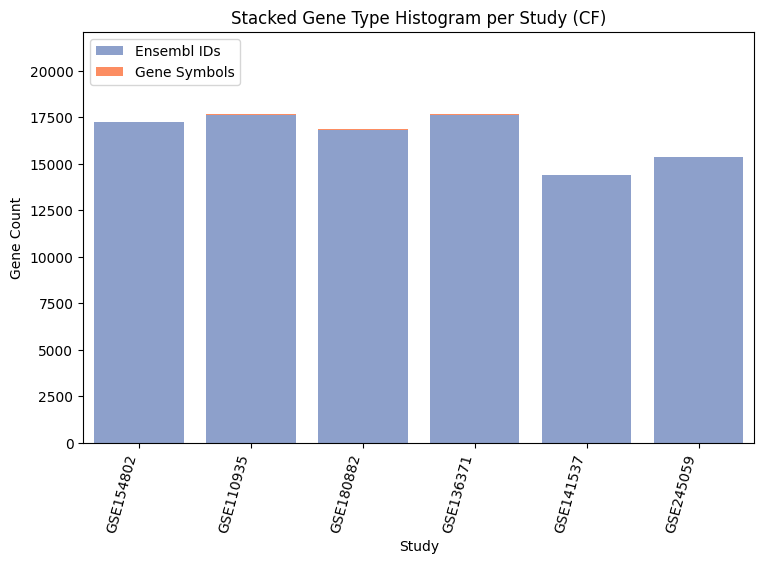

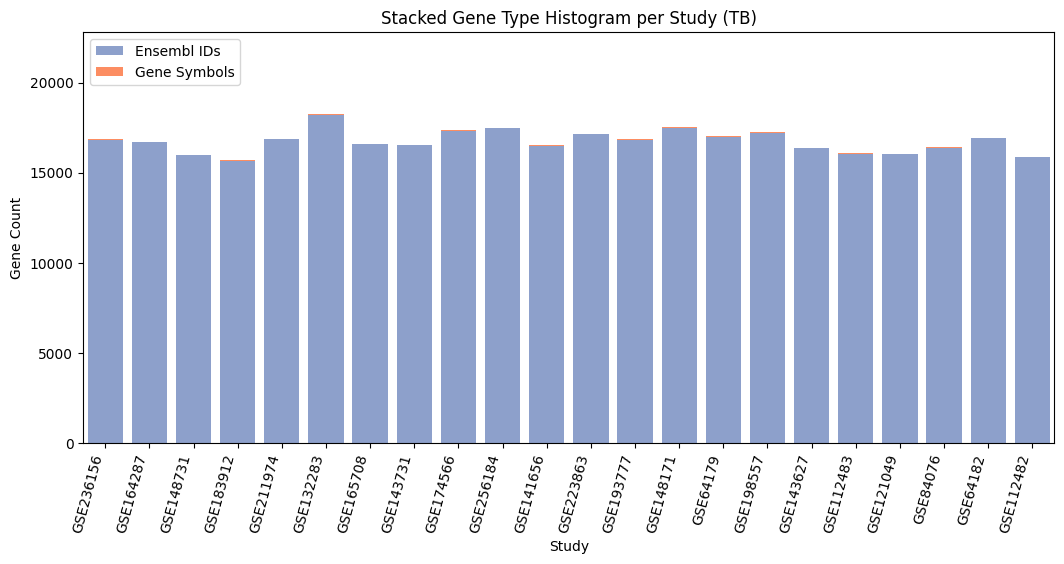

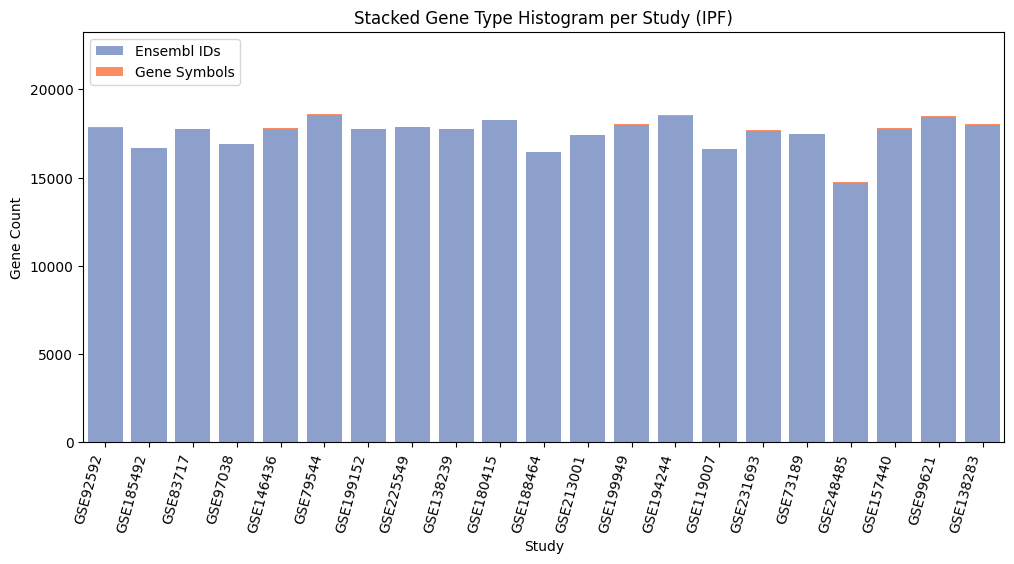

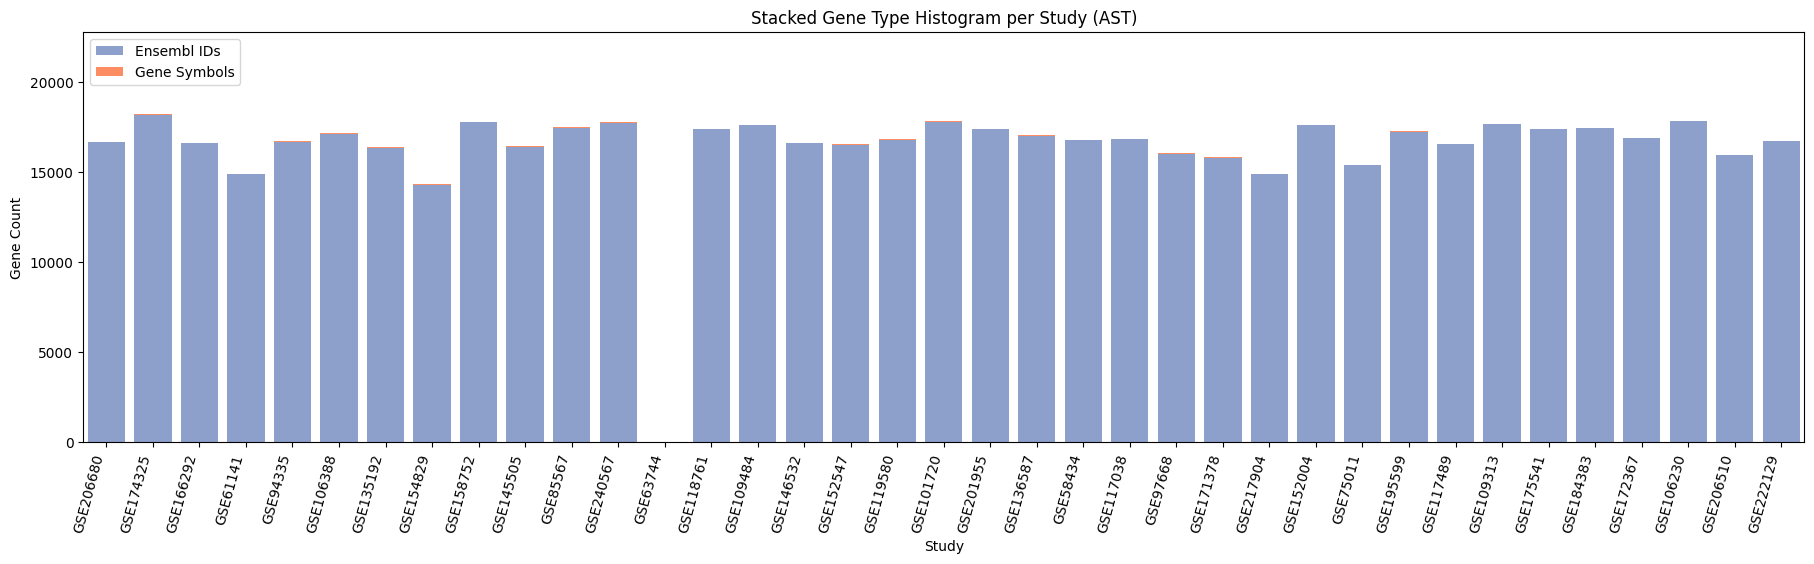

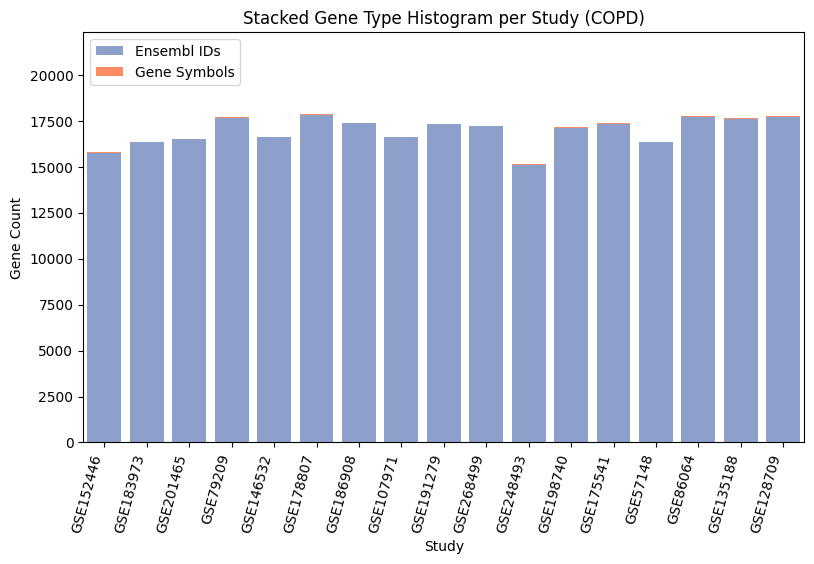

In [ ]:
plot_stacked_gene_type_histogram(TB_output_path, disease_name='TB')

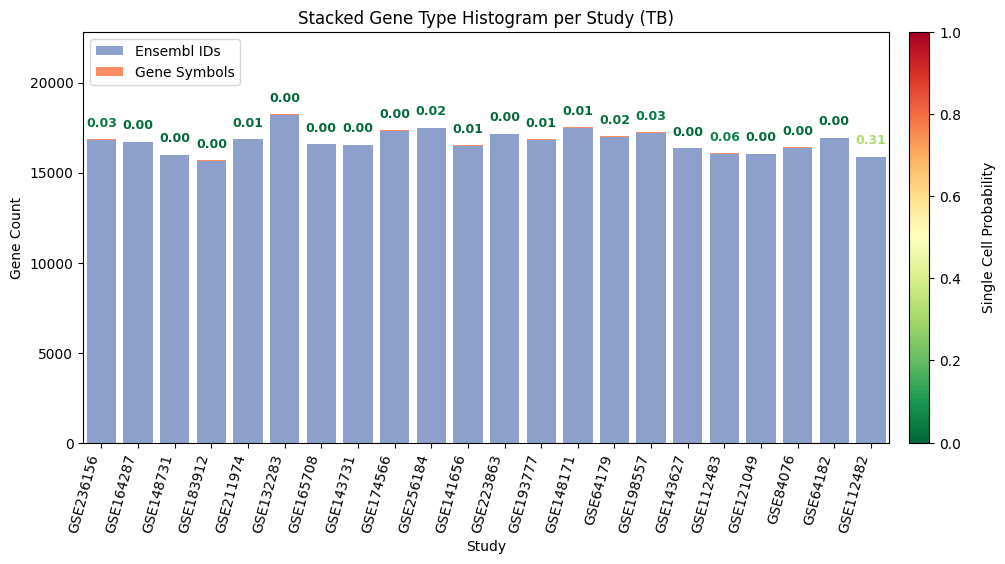

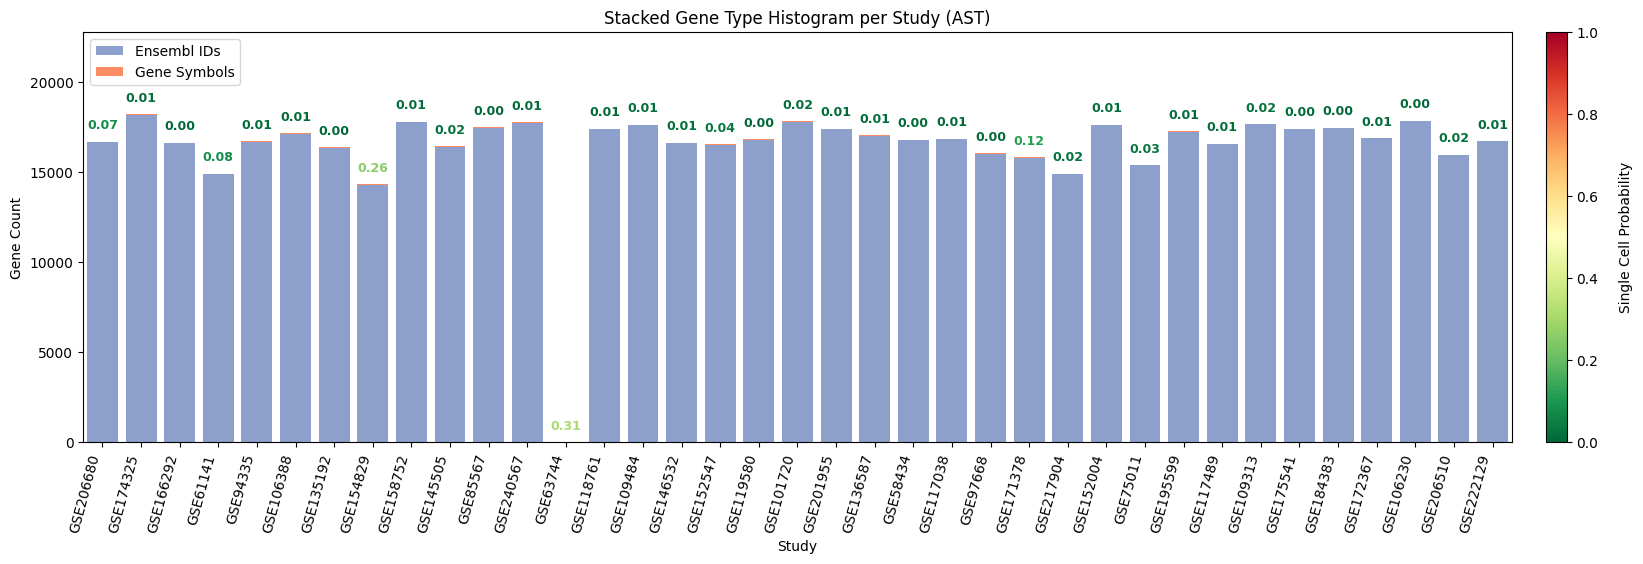

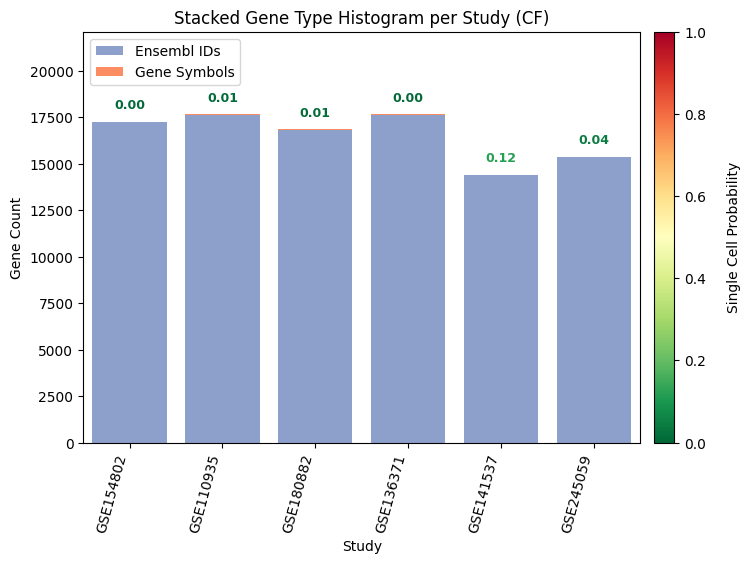

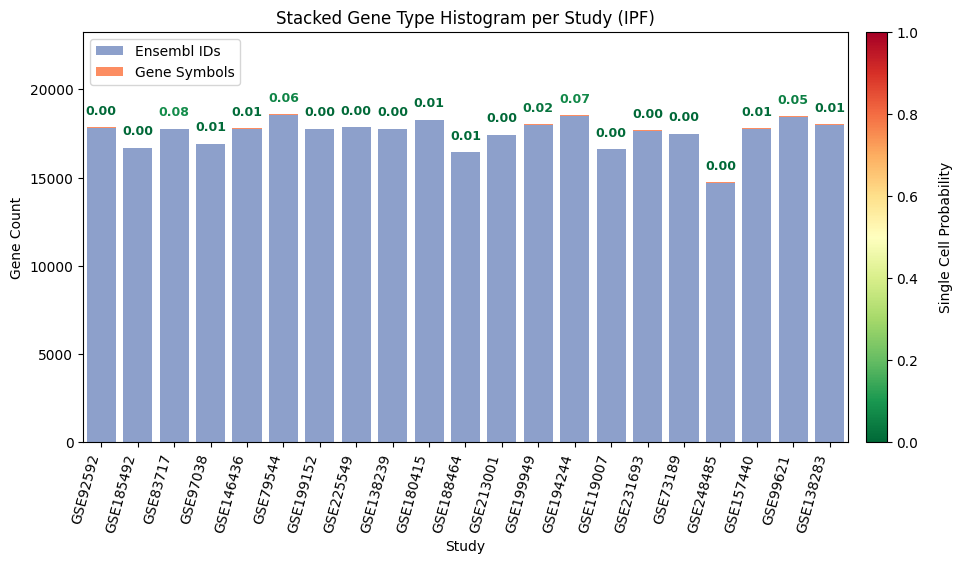

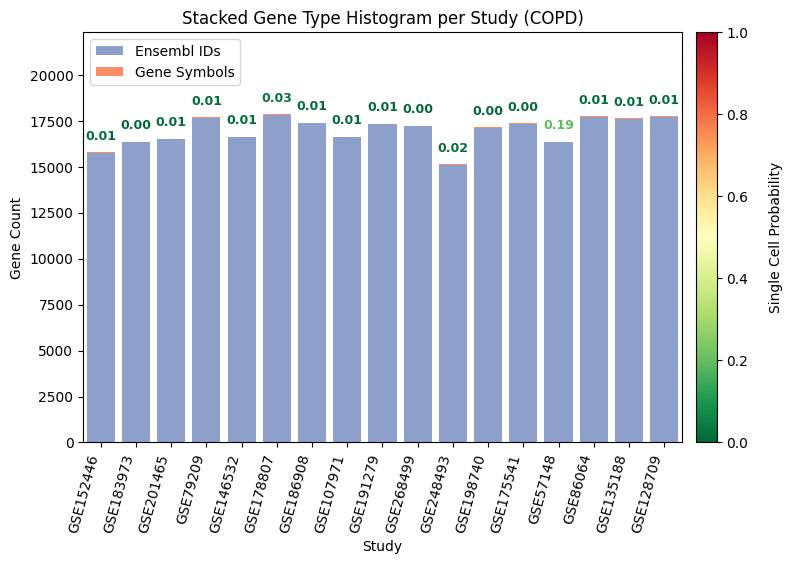

In [ ]:
plot_stacked_gene_type_histogram(TB_output_path, tbscp, disease_name='TB')

In [84]:
# print scp - sort by single cell probability high to low
tbscp.sort_values(by='singlecellprobability', ascending=False)

,series_id,singlecellprobability
0,GSE112482,0.314966
1,GSE112483,0.060914
17,GSE236156,0.034067
14,GSE198557,0.029175
18,GSE256184,0.017399
19,"GSE64179,GSE64183",0.017252
7,GSE148171,0.011476
13,GSE193777,0.008689
15,"GSE211974,GSE211977",0.006548
4,GSE141656,0.005133


### Histogram of Sample information across all studies

In [90]:
TBlabels.columns

Index(['GSE_ID', 'GSM_ID', 'CLASSIFICATION', 'CLASSIFICATION_STANDARDIZED',
       'SAMPLE_TYPE', 'CELL_SOURCE', 'CELL_SOURCE_CLEAN', 'TISSUE_SOURCE',
       'TISSUE_SOURCE_CLEAN', 'CL:CODE', 'UBERON:CODE', 'CONTEXT'],
      dtype='object')

### Sparsity Visualization

In [117]:
from matplotlib.patches import Patch

def create_sparsity_barchart(summary_df, disease, scp_df=None,
                             add_colorbar=True, cbar_shrink=0.85):
    """
    Bar chart of mean sparsity per series.
    If scp_df provided (columns: ['series_id','singlecellprobability']) annotate each bar with SCP.
    Colorbar shows SCP scale. Bar legend (Mean Sparsity) removed per request.
    """
    files = summary_df.index
    series_clean = [f.replace('.tsv', '') for f in files]
    x_pos = np.arange(len(files))
    mean_values = summary_df['mean']

    fig_width = max(10, len(files) * 0.5)
    fig, ax = plt.subplots(figsize=(fig_width, 6))
    # No label on bars (no legend for bar color)
    ax.bar(x_pos, mean_values, color='steelblue')

    ax.set_xlabel('Series')
    ax.set_ylabel('Mean Sparsity')
    ax.set_title(f'Mean Sparsity by Series for {disease}', fontsize=16)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(series_clean, rotation=45, ha="right")
    ax.set_ylim(0, 1)

    # Track if we successfully plotted any SCP values (for colorbar)
    added_any_scp = False

    if scp_df is not None and not scp_df.empty and 'series_id' in scp_df.columns:
        scp = scp_df.copy()
        scp['singlecellprobability'] = pd.to_numeric(scp['singlecellprobability'], errors='coerce')

        # Map series_id -> probability (handle comma separated)
        scp_map = {}
        for _, row in scp.iterrows():
            for sid in str(row['series_id']).split(','):
                sid_clean = sid.strip()
                if sid_clean:
                    scp_map[sid_clean] = row['singlecellprobability']

        cmap = plt.get_cmap('RdYlGn_r')
        norm = mcolors.Normalize(vmin=0, vmax=1)
        annotation_offset = 0.02

        for i, sid in enumerate(series_clean):
            prob = scp_map.get(sid)
            if prob is None:
                # fuzzy fallback
                for key in scp_map:
                    if sid in key or key in sid:
                        prob = scp_map[key]
                        break
            y_top = mean_values.iloc[i]
            if prob is not None and not np.isnan(prob):
                added_any_scp = True
                color = cmap(norm(prob))
                ax.text(i, min(0.995, y_top + annotation_offset),
                        f"{prob:.2f}", ha='center', va='bottom',
                        fontsize=9, fontweight='bold', color=color)
            else:
                ax.text(i, min(0.995, y_top + annotation_offset),
                        "NA", ha='center', va='bottom',
                        fontsize=8, color='gray')

        # Only add colorbar if we have at least one valid SCP value
        if add_colorbar and added_any_scp:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])  # required for colorbar
            # Explicitly pass ax to avoid ValueError in some contexts
            fig.colorbar(sm, ax=ax, pad=0.02, shrink=cbar_shrink).set_label('Single Cell Probability', labelpad=10)

    fig.tight_layout()
    filename = f'images/Sparsity/{disease.replace(" ", "_")}_sparsity_barchart.png'
    fig.savefig(filename, dpi=300)
    print(f"Bar chart saved to {filename}")

def get_sparsity(expression_path, disease: str, scp_df=None):
    """
    Calculates sparsity for each sample in all expression files and generates a summary visualization.
    scp_df to annotate bars with single cell probability.
    """
    sparsity_dict = {}
    files = sorted([f for f in os.listdir(expression_path) if f.endswith('.tsv')])
    for file in files:
        df = pd.read_csv(os.path.join(expression_path, file), sep='\t')

        samples_df = df.drop(df.columns[0], axis=1)
        sparsity_series = (samples_df == 0).mean()
        sparsity_df = sparsity_series.reset_index()
        sparsity_df.columns = ['Sample', 'Sparsity']
        sparsity_dict[file] = sparsity_df

    # Calculate summary statistics
    summary_stats = {
        file: sdf['Sparsity'].agg(['mean', 'min', 'max'])
        for file, sdf in sparsity_dict.items()
    }

    # Create and print the summary DataFrame
    summary_df = pd.DataFrame.from_dict(summary_stats, orient='index')
    print("Summary DataFrame:")
    print(summary_df)

    create_sparsity_barchart(summary_df, disease, scp_df=scp_df)
    
    # Save the summary data to a CSV file for record-keeping
    summary_df.to_csv(f'images/Sparsity/{disease}_sparsity_summary.csv')
    print(f"\nSummary data saved to images/Sparsity/{disease}_sparsity_summary.csv")


    return sparsity_dict

#### TB Sparsity

Summary DataFrame:
                   mean       min       max
GSE100897.tsv  0.191188  0.156147  0.212070
GSE110564.tsv  0.096375  0.069037  0.113978
GSE112482.tsv  0.478141  0.168888  0.799925
GSE112483.tsv  0.296449  0.176032  0.492003
GSE121049.tsv  0.234185  0.219213  0.257064
GSE132283.tsv  0.093445  0.052937  0.119309
GSE141656.tsv  0.204833  0.183762  0.217187
GSE143627.tsv  0.206534  0.195223  0.221239
GSE143731.tsv  0.201967  0.196663  0.208231
GSE148171.tsv  0.146829  0.117497  0.192664
GSE148731.tsv  0.236035  0.198635  0.276469
GSE164287.tsv  0.210917  0.179443  0.236966
GSE165708.tsv  0.202422  0.144685  0.249547
GSE174566.tsv  0.138921  0.118936  0.156520
GSE183912.tsv  0.279954  0.267299  0.287024
GSE193777.tsv  0.186566  0.111472  0.314852
GSE198557.tsv  0.146053  0.117497  0.192718
GSE211974.tsv  0.161804  0.151349  0.171873
GSE223863.tsv  0.177616  0.143672  0.243043
GSE236156.tsv  0.188033  0.144632  0.276575
GSE256184.tsv  0.118623  0.101077  0.133223
GSE64179.tsv 

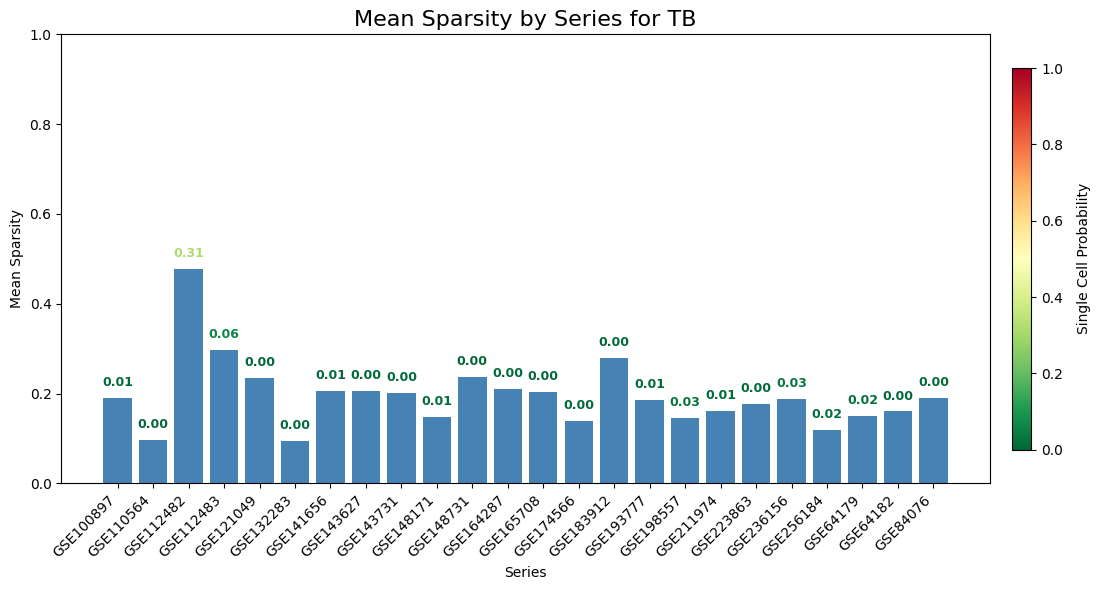

In [ ]:
tb_sparsity = get_sparsity(TB_proteincoding_path, "TB", tbscp)

In [ ]:
tb_sparsity["GSE112482.tsv"].sort_values(by="Sparsity", ascending=False)

,Sample,Sparsity
27,GSM3070991,0.799925
13,GSM3070977,0.760742
30,GSM3070994,0.750080
15,GSM3070979,0.743576
14,GSM3070978,0.742830
...,...,...
64,GSM3071035,0.231475
47,GSM3071011,0.203913
46,GSM3071010,0.194637
86,GSM3071059,0.183708
